# 07 — Point vs Neighbourhood Extraction

This notebook extracts climate data from NARCliM2.0 rotated WRF grids using two methods:

- **Single-point extraction** — value at the nearest grid cell to a specified lat/lon
- **Neighbourhood extraction** — spatially averaged value across surrounding grid cells within a specified radius

| Method | When to use |
|---|---|
| **Single point** | Comparing to a station observation; site is well-represented by one model cell |
| **Neighbourhood average** | Reducing sub-grid noise; site sits between grid nodes; catchment-scale comparisons |

---

## Contents

1. [Imports](#Imports)
2. [Configuration](#Configuration)
3. [Load Dataset](#Load-Dataset)
4. [Create Land Mask](#Create-Land-Mask)
5. [Core Extraction Functions](#Core-Extraction-Functions)
6. [Extract All Sites](#Extract-All-Sites)
7. [Results](#Results)
8. [Export](#Export)

## Imports

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from shapely.geometry import Point
from shapely.prepared import prep
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from climate_utils import kelvin_to_celsius

print("All imports successful")

All imports successful


## Configuration

> **To run this notebook for a different dataset or sites**, edit only this cell.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
BASE_URL     = "https://dapds00.nci.org.au/thredds/dodsC/zz63/NARCliM2-0/output-CMIP6/DD"
domain       = "AUS-18"
organisation = "NSW-Government"
gcm          = "ACCESS-ESM1-5"
rcm          = "NARCliM2-0-WRF412R3"
experiment   = "ssp126"
variant      = "r6i1p1f1"
frequency    = "mon"
variable     = "tasmax"
version      = "v1-r1"
file_period  = "201501-201512"

# ══════════════════════════════════════════════════════════════════════════════
# EXTRACTION SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
RADIUS_KM = 35.0           # Neighbourhood radius in km
MIN_LAND_CELLS = 5         # Minimum land cells for stable averaging
ADAPTIVE_RADIUS = True     # Auto-expand radius if too few land cells
MAX_RADIUS_KM = 75.0       # Maximum radius for adaptive expansion

# ══════════════════════════════════════════════════════════════════════════════
# SITES
# ══════════════════════════════════════════════════════════════════════════════
SITES = [
    {"label": "Perth",    "lat": -32.0,  "lon": 116.0},
    {"label": "Broome",   "lat": -17.96, "lon": 122.24},
    {"label": "Albany",   "lat": -35.02, "lon": 117.88},
    {"label": "Karratha", "lat": -20.74, "lon": 116.85},
]

## Load Dataset

In [13]:
file_url = (
    f"{BASE_URL}/{domain}/{organisation}/{gcm}/{experiment}/{variant}/"
    f"{rcm}/{version}/{frequency}/{variable}/latest/"
    f"{variable}_{domain}_{gcm}_{experiment}_{variant}_"
    f"{organisation}_{rcm}_{version}_{frequency}_{file_period}.nc"
)

print("Loading dataset...")
ds = xr.open_dataset(file_url)
da = kelvin_to_celsius(ds[variable])
lat2d = ds["lat"]
lon2d = ds["lon"]

print(f"\nDataset loaded:")
print(f"  Variable   : {variable}")
print(f"  Grid       : {da.sizes['rlat']} × {da.sizes['rlon']} ({da.sizes['rlat'] * da.sizes['rlon']:,} cells)")
print(f"  Time steps : {da.time.size}")
print(f"  Lat range  : {float(lat2d.min()):.2f}° to {float(lat2d.max()):.2f}°")
print(f"  Lon range  : {float(lon2d.min()):.2f}° to {float(lon2d.max()):.2f}°")

Loading dataset...

Dataset loaded:
  Variable   : tasmax
  Grid       : 321 × 497 (159,537 cells)
  Time steps : 12
  Lat range  : -52.57° to 12.09°
  Lon range  : -180.00° to 180.00°


## Create Land Mask

The land mask is created from Natural Earth coastlines to accurately distinguish land from ocean grid cells. This ensures that neighbourhood averages only include land cells, which is important for coastal sites where ocean temperatures would otherwise bias the results.

In [14]:
def create_land_mask(lat2d, lon2d):
    """
    Create a land mask from Natural Earth coastlines.
    
    Parameters
    ----------
    lat2d, lon2d : xr.DataArray
        2D coordinate arrays from the rotated grid
    
    Returns
    -------
    xr.DataArray
        Boolean mask (True = land, False = ocean)
    """
    print("Creating land mask from Natural Earth coastlines...")
    
    land_shp = shpreader.natural_earth(resolution='50m', category='physical', name='land')
    land_geoms = list(shpreader.Reader(land_shp).geometries())
    land = unary_union(land_geoms)
    prepared_land = prep(land)
    
    lats, lons = lat2d.values, lon2d.values
    lons_norm = ((lons + 180) % 360) - 180  # Normalize to -180 to 180
    
    mask = np.array([
        [prepared_land.contains(Point(lons_norm[i,j], lats[i,j])) 
         for j in range(lats.shape[1])]
        for i in range(lats.shape[0])
    ])
    
    print(f"  Land cells : {mask.sum():,} ({100*mask.sum()/mask.size:.1f}%)")
    print(f"  Ocean cells: {(~mask).sum():,} ({100*(~mask).sum()/mask.size:.1f}%)")
    
    return xr.DataArray(mask, dims=lat2d.dims, coords=lat2d.coords)


land_mask_da = create_land_mask(lat2d, lon2d)

Creating land mask from Natural Earth coastlines...
  Land cells : 27,222 (17.1%)
  Ocean cells: 132,315 (82.9%)


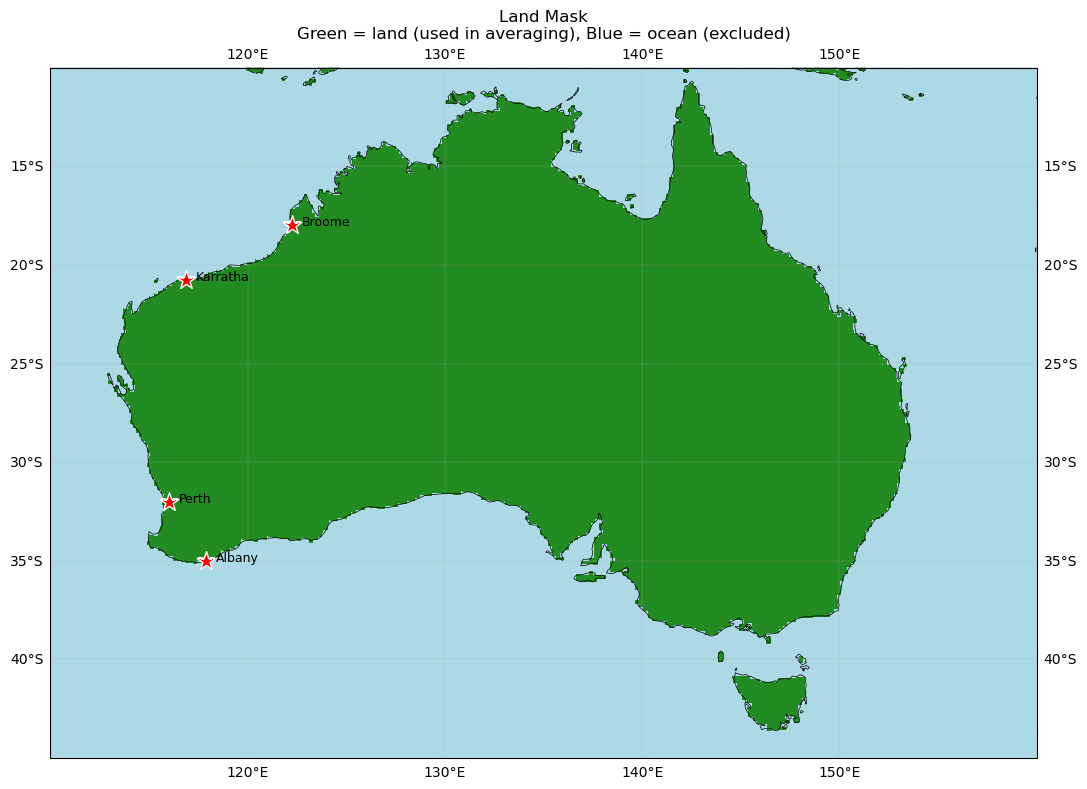

In [15]:
# Visualize land mask
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.pcolormesh(
    lon2d.values, lat2d.values, land_mask_da.values.astype(int),
    cmap=ListedColormap(['lightblue', 'forestgreen']),
    transform=ccrs.PlateCarree(), vmin=0, vmax=1
)
ax.coastlines(resolution='50m', color='black', linewidth=0.5)
ax.set_extent([110, 160, -45, -10], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

for site in SITES:
    ax.scatter(site["lon"], site["lat"], marker="*", s=200, c="red",
               edgecolors="white", linewidths=1, zorder=10, transform=ccrs.PlateCarree())
    ax.text(site["lon"]+0.5, site["lat"], site["label"], fontsize=9, transform=ccrs.PlateCarree())

ax.set_title("Land Mask\nGreen = land (used in averaging), Blue = ocean (excluded)")
plt.tight_layout()
plt.show()

## Core Extraction Functions

The extraction uses:
- **Haversine distance** — correct great-circle distance calculation on curved Earth
- **Radius-based selection** — neighbourhood defined in km, not grid indices (which would be distorted on a rotated grid)
- **Land masking** — excludes ocean cells from neighbourhood averaging
- **Area weighting** — cosine-latitude weighting to account for varying grid cell size

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance using the haversine formula.
    
    Parameters
    ----------
    lat1, lon1 : float or array
        Coordinates of first point(s) in decimal degrees
    lat2, lon2 : float or array
        Coordinates of second point(s) in decimal degrees
    
    Returns
    -------
    float or array
        Distance in kilometres
    """
    R = 6371.0  # Earth radius in km
    lat1_r, lat2_r = np.radians(lat1), np.radians(lat2)
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def extract_point_and_neighbourhood(
    da, lat2d, lon2d, target_lat, target_lon,
    radius_km=25.0, land_mask=None,
    min_land_cells=3, adaptive_radius=False, max_radius_km=75.0,
    verbose=True
):
    """
    Extract point and neighbourhood time series from a rotated WRF grid.
    
    Parameters
    ----------
    da : xr.DataArray
        Data array with dimensions (time, rlat, rlon)
    lat2d, lon2d : xr.DataArray
        2D coordinate arrays (rlat, rlon)
    target_lat, target_lon : float
        Target location in decimal degrees
    radius_km : float
        Neighbourhood radius in kilometres
    land_mask : xr.DataArray, optional
        Boolean mask (True = land)
    min_land_cells : int
        Minimum number of land cells required for stable averaging
    adaptive_radius : bool
        If True, automatically expand radius until min_land_cells is met
    max_radius_km : float
        Maximum radius for adaptive expansion
    verbose : bool
        Print diagnostic information
    
    Returns
    -------
    dict
        Contains ts_point, ts_neighbourhood, meta, combined_mask
    """
    warnings_list = []
    
    # Calculate haversine distance from target to all grid cells
    dist_km = haversine(lat2d.values, lon2d.values, target_lat, target_lon)
    dist_da = xr.DataArray(dist_km, dims=lat2d.dims, coords=lat2d.coords)
    
    # Find nearest cell
    idx = dist_da.argmin(dim=("rlat", "rlon"))
    rlat_idx, rlon_idx = idx["rlat"].item(), idx["rlon"].item()
    nearest_lat = float(lat2d.isel(rlat=rlat_idx, rlon=rlon_idx))
    nearest_lon = float(lon2d.isel(rlat=rlat_idx, rlon=rlon_idx))
    offset_km = float(dist_da.isel(rlat=rlat_idx, rlon=rlon_idx))
    
    # Single point extraction
    ts_point = da.isel(rlat=rlat_idx, rlon=rlon_idx)
    
    # Adaptive radius expansion
    current_radius = radius_km
    radius_expanded = False
    
    while True:
        radius_mask = dist_da <= current_radius
        n_cells_in_radius = int(radius_mask.sum())
        
        if land_mask is not None:
            combined_mask = radius_mask & land_mask
            n_cells_land = int(combined_mask.sum())
            n_cells_ocean = int((radius_mask & ~land_mask).sum())
        else:
            combined_mask = radius_mask
            n_cells_land = n_cells_in_radius
            n_cells_ocean = 0
        
        if n_cells_land >= min_land_cells:
            break
        
        if adaptive_radius and current_radius < max_radius_km:
            current_radius += 10
            radius_expanded = True
        else:
            if n_cells_land < min_land_cells:
                warnings_list.append(
                    f"Only {n_cells_land} land cells (< {min_land_cells} minimum)"
                )
            break
    
    if radius_expanded:
        warnings_list.append(
            f"Radius expanded: {radius_km:.0f} → {current_radius:.0f} km"
        )
    
    n_cells_used = int(combined_mask.sum())
    
    # Area-weighted mean (cosine-latitude weighting)
    weights = np.cos(np.radians(lat2d)).where(combined_mask, other=0)
    da_masked = da.where(combined_mask)
    ts_neighbourhood = (da_masked * weights).sum(dim=("rlat", "rlon")) / weights.sum(dim=("rlat", "rlon"))
    ts_neighbourhood.attrs = da.attrs.copy()
    
    # Statistics
    point_mean = float(ts_point.mean())
    nbhd_mean = float(ts_neighbourhood.mean())
    diff = nbhd_mean - point_mean
    
    # Status
    if abs(diff) > 2.0:
        status = "!!!"
    elif abs(diff) > 1.5:
        status = "*"
    else:
        status = ""
    
    meta = {
        "target_lat": target_lat,
        "target_lon": target_lon,
        "nearest_lat": nearest_lat,
        "nearest_lon": nearest_lon,
        "offset_km": offset_km,
        "radius_km": current_radius,
        "radius_expanded": radius_expanded,
        "original_radius_km": radius_km,
        "n_cells_in_radius": n_cells_in_radius,
        "n_cells_land": n_cells_land,
        "n_cells_ocean": n_cells_ocean,
        "n_cells_used": n_cells_used,
        "point_mean": point_mean,
        "nbhd_mean": nbhd_mean,
        "diff": diff,
        "status": status,
        "warnings": warnings_list,
    }
    
    if verbose:
        print(f"  Target     : ({target_lat:.2f}°, {target_lon:.2f}°)")
        print(f"  Nearest    : ({nearest_lat:.2f}°, {nearest_lon:.2f}°) — {offset_km:.1f} km offset")
        radius_str = f"{current_radius:.0f} km" + (f" (expanded from {radius_km:.0f})" if radius_expanded else "")
        print(f"  Radius     : {radius_str}")
        print(f"  Cells      : {n_cells_in_radius} total → {n_cells_land} land, {n_cells_ocean} ocean")
        print(f"  Point mean : {point_mean:.2f}°C")
        print(f"  Nbhd mean  : {nbhd_mean:.2f}°C")
        print(f"  Difference : {diff:+.2f}°C {status}")
        for w in warnings_list:
            print(f"  ⚠ {w}")
    
    return {
        "ts_point": ts_point,
        "ts_neighbourhood": ts_neighbourhood,
        "meta": meta,
        "combined_mask": combined_mask,
    }

## Extract All Sites

In [17]:
print(f"Extraction settings:")
print(f"  Default radius    : {RADIUS_KM} km")
print(f"  Min land cells    : {MIN_LAND_CELLS}")
print(f"  Adaptive radius   : {ADAPTIVE_RADIUS} (max {MAX_RADIUS_KM} km)")
print()

results = {}

for site in SITES:
    print(f"{'─'*60}")
    print(f"{site['label']}")
    print(f"{'─'*60}")
    
    result = extract_point_and_neighbourhood(
        da, lat2d, lon2d,
        target_lat=site["lat"],
        target_lon=site["lon"],
        radius_km=RADIUS_KM,
        land_mask=land_mask_da,
        min_land_cells=MIN_LAND_CELLS,
        adaptive_radius=ADAPTIVE_RADIUS,
        max_radius_km=MAX_RADIUS_KM,
    )
    results[site["label"]] = result
    print()

Extraction settings:
  Default radius    : 35.0 km
  Min land cells    : 5
  Adaptive radius   : True (max 75.0 km)

────────────────────────────────────────────────────────────
Perth
────────────────────────────────────────────────────────────
  Target     : (-32.00°, 116.00°)
  Nearest    : (-31.95°, 116.02°) — 6.3 km offset
  Radius     : 35 km
  Cells      : 10 total → 10 land, 0 ocean
  Point mean : 25.88°C
  Nbhd mean  : 25.96°C
  Difference : +0.08°C 

────────────────────────────────────────────────────────────
Broome
────────────────────────────────────────────────────────────
  Target     : (-17.96°, 122.24°)
  Nearest    : (-17.98°, 122.33°) — 9.3 km offset
  Radius     : 35 km
  Cells      : 10 total → 5 land, 5 ocean
  Point mean : 34.65°C
  Nbhd mean  : 34.23°C
  Difference : -0.41°C 

────────────────────────────────────────────────────────────
Albany
────────────────────────────────────────────────────────────
  Target     : (-35.02°, 117.88°)
  Nearest    : (-34.96°, 1

## Results

In [18]:
# Summary table
rows = []
for site in SITES:
    m = results[site["label"]]["meta"]
    radius_str = f"{m['radius_km']:.0f}" + ("*" if m['radius_expanded'] else "")
    rows.append({
        "Site": site["label"],
        "Offset (km)": f"{m['offset_km']:.1f}",
        "Radius (km)": radius_str,
        "Land cells": m["n_cells_land"],
        "Ocean cells": m["n_cells_ocean"],
        "Point (°C)": f"{m['point_mean']:.2f}",
        "Nbhd (°C)": f"{m['nbhd_mean']:.2f}",
        "Diff (°C)": f"{m['diff']:+.2f}",
    })

summary_df = pd.DataFrame(rows)
print("Summary")
print("═" * 80)
print(summary_df.to_string(index=False))
print()
print("* = radius was expanded to meet minimum land cell requirement")
print("Expected point–neighbourhood difference: ±0.5 to ±1.5°C")

Summary
════════════════════════════════════════════════════════════════════════════════
    Site Offset (km) Radius (km)  Land cells  Ocean cells Point (°C) Nbhd (°C) Diff (°C)
   Perth         6.3          35          10            0      25.88     25.96     +0.08
  Broome         9.3          35           5            5      34.65     34.23     -0.41
  Albany         7.8          35           5            5      20.86     20.60     -0.26
Karratha         4.9          35           6            4      34.79     35.17     +0.37

* = radius was expanded to meet minimum land cell requirement
Expected point–neighbourhood difference: ±0.5 to ±1.5°C


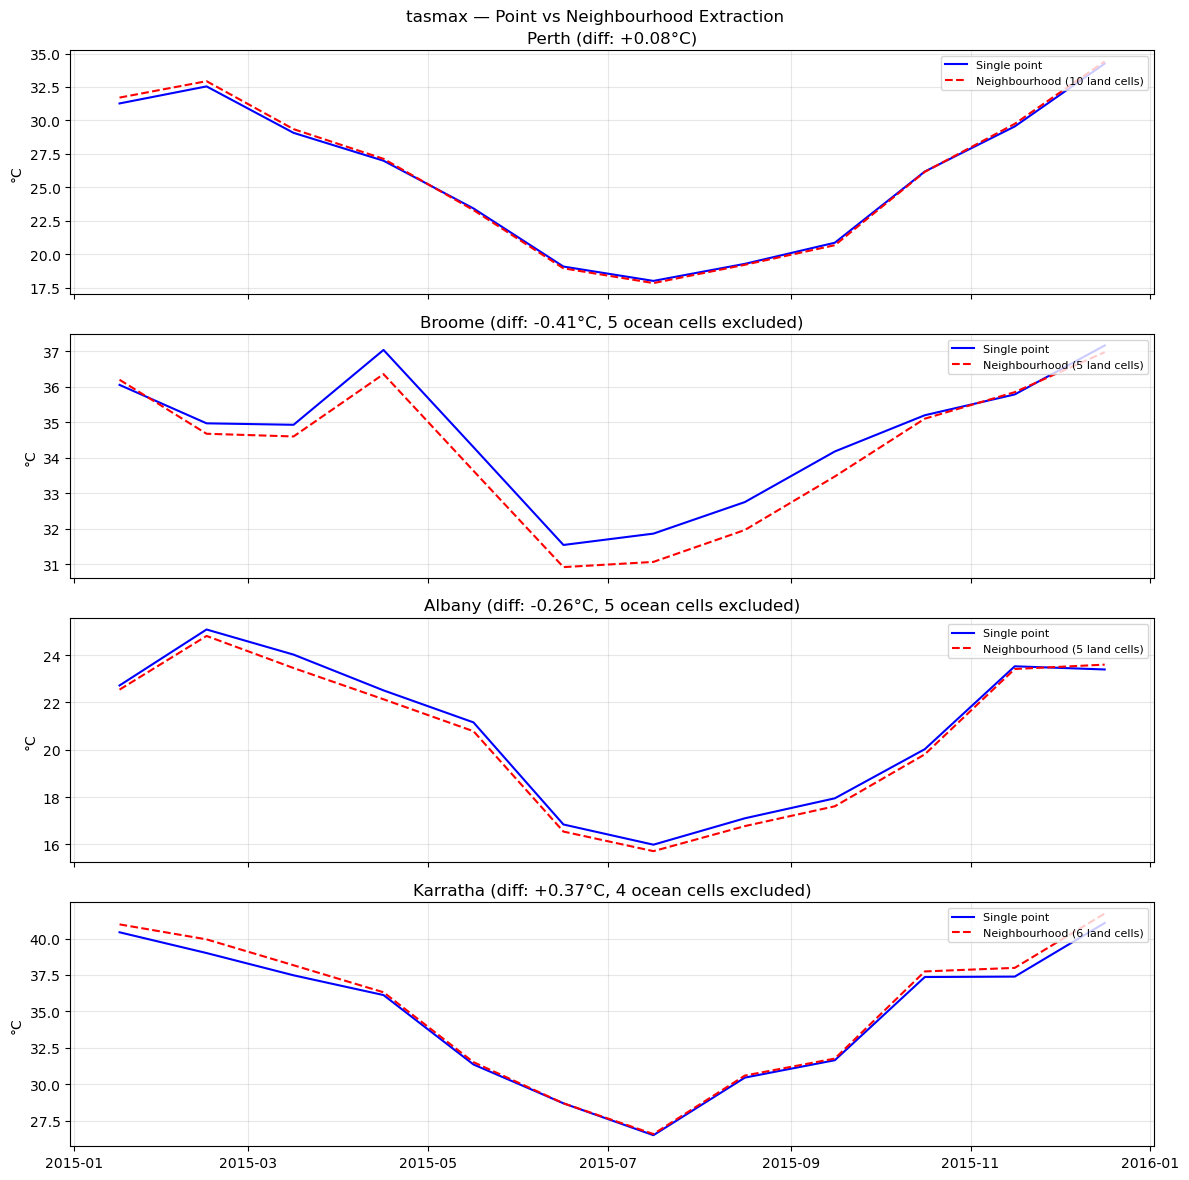

In [19]:
# Time series plots
fig, axes = plt.subplots(len(SITES), 1, figsize=(12, 3*len(SITES)), sharex=True)

for ax, site in zip(axes, SITES):
    r = results[site["label"]]
    m = r["meta"]
    t = pd.to_datetime(r["ts_point"].time.values)
    
    ax.plot(t, r["ts_point"].values, 'b-', lw=1.5, label="Single point")
    ax.plot(t, r["ts_neighbourhood"].values, 'r--', lw=1.5, 
            label=f"Neighbourhood ({m['n_cells_used']} land cells)")
    
    title = f"{site['label']} (diff: {m['diff']:+.2f}°C"
    if m['n_cells_ocean'] > 0:
        title += f", {m['n_cells_ocean']} ocean cells excluded"
    if m['radius_expanded']:
        title += f", radius expanded to {m['radius_km']:.0f} km"
    title += ")"
    
    ax.set_title(title)
    ax.set_ylabel("°C")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{variable} — Point vs Neighbourhood Extraction", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Detailed statistics comparison
for site in SITES:
    r = results[site["label"]]
    m = r["meta"]
    
    ts_p = r["ts_point"]
    ts_n = r["ts_neighbourhood"]
    
    stats = pd.DataFrame({
        "Single point": {
            "Mean": float(ts_p.mean()),
            "Std": float(ts_p.std()),
            "Min": float(ts_p.min()),
            "Max": float(ts_p.max()),
        },
        f"Neighbourhood ({m['n_cells_used']} cells)": {
            "Mean": float(ts_n.mean()),
            "Std": float(ts_n.std()),
            "Min": float(ts_n.min()),
            "Max": float(ts_n.max()),
        },
    }).T.round(2)
    
    print(f"\n{site['label']}")
    print(stats)


Perth
                           Mean   Std    Min    Max
Single point              25.88  5.41  18.03  34.25
Neighbourhood (10 cells)  25.96  5.59  17.86  34.41

Broome
                          Mean   Std    Min    Max
Single point             34.65  1.76  31.54  37.17
Neighbourhood (5 cells)  34.23  1.97  30.92  36.98

Albany
                          Mean   Std    Min    Max
Single point             20.86  3.04  15.98  25.08
Neighbourhood (5 cells)  20.60  3.08  15.71  24.81

Karratha
                          Mean   Std    Min    Max
Single point             34.79  4.63  26.51  41.06
Neighbourhood (6 cells)  35.17  4.88  26.59  41.71


## Export

In [21]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

all_dfs = []
for site in SITES:
    r = results[site["label"]]
    m = r["meta"]
    df = pd.DataFrame({
        "time": pd.to_datetime(r["ts_point"].time.values),
        "site": site["label"],
        f"{variable}_point_degC": r["ts_point"].values,
        f"{variable}_neighbourhood_degC": r["ts_neighbourhood"].values,
        "difference_degC": r["ts_neighbourhood"].values - r["ts_point"].values,
        "radius_km": m["radius_km"],
        "n_land_cells": m["n_cells_land"],
        "n_ocean_excluded": m["n_cells_ocean"],
    })
    all_dfs.append(df)

combined = pd.concat(all_dfs).set_index(["time", "site"])
csv_path = output_dir / f"{variable}_point_vs_neighbourhood.csv"
combined.to_csv(csv_path)

print(f"Exported: {csv_path}")
print(f"  {len(combined)} rows, {len(SITES)} sites")
combined.head(12)

Exported: output/tasmax_point_vs_neighbourhood.csv
  48 rows, 4 sites


,,tasmax_point_degC,tasmax_neighbourhood_degC,difference_degC,radius_km,n_land_cells,n_ocean_excluded
time,site,,,,,,
2015-01-16 12:00:00,Perth,31.272400,31.708551,0.436151,35.0,10,0
2015-02-15 00:00:00,Perth,32.544159,32.934125,0.389966,35.0,10,0
2015-03-16 12:00:00,Perth,29.077118,29.354770,0.277652,35.0,10,0
2015-04-16 00:00:00,Perth,26.997101,27.138555,0.141454,35.0,10,0
2015-05-16 12:00:00,Perth,23.434937,23.310666,-0.124271,35.0,10,0
2015-06-16 00:00:00,Perth,19.096588,18.965035,-0.131553,35.0,10,0
2015-07-16 12:00:00,Perth,18.025848,17.863945,-0.161903,35.0,10,0
2015-08-16 12:00:00,Perth,19.299286,19.230280,-0.069006,35.0,10,0
2015-09-16 00:00:00,Perth,20.875854,20.691051,-0.184803,35.0,10,0


---

## Method Notes

### Distance Calculation
The **haversine formula** is used to calculate great-circle distances, which correctly accounts for Earth's curvature. This is essential for rotated WRF grids where Euclidean distance on lat/lon coordinates would give incorrect results.

### Neighbourhood Selection
The neighbourhood is defined by a **radius in kilometres**, not by grid indices. This ensures a consistent physical size regardless of grid distortion in the rotated coordinate system.

### Land Masking
A land mask derived from **Natural Earth coastlines** is applied to exclude ocean grid cells from the neighbourhood average. This is important for coastal sites where ocean temperatures would otherwise bias the results.

### Area Weighting
**Cosine-latitude weighting** is applied to account for the fact that grid cells at different latitudes represent different physical areas.


---
